# **Video Game Sales Analysis: Planning Ice's 2017 Campaign**

## **1. Introduction**

 **1.1. Business context**

Ice is an online video game store. The goal of this project is to identify patterns in historical sales that can help plan advertising campaigns for 2017. 

**1.2. Objectives**
- Identify promising platforms and genres.
- Compare consumer preferences across North America, Europe, and Japan.
- Examine the relationship between review scores and sales.
- Test the proposed hypotheses about user scores.

## **2. Data Overview**

 **2.1 Importing libraries and dataset**

In [66]:
# importing necessary libraries

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [67]:
game_data = pd.read_csv(
    r'C:\Users\fredd\OneDrive\Desktop\Triple Ten Bootcamp\Sprint 6\Sprint_6_Project\games.csv'
) # reading data

 **2.2. Preparing the dataset**

In [68]:
print(game_data.info()) # obtaining information about the dataset

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 2.0 MB
None


In [69]:
print(game_data.head())

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  


In [70]:
print(f'The dataset contains {game_data.shape[0]} rows and {game_data.shape[1]} columns.')

The dataset contains 16715 rows and 11 columns.


In [71]:
print(f'The dataset contains {game_data.isna().sum().sum()} missing values.')

The dataset contains 22318 missing values.


In [72]:
print(f'The dataset contains {game_data.duplicated().sum()} duplicate rows.')

The dataset contains 0 duplicate rows.


In [73]:
game_data.columns = game_data.columns.str.lower() # transforming column names to lowercase

In [74]:
game_data['user_score'] = pd.to_numeric(game_data['user_score'], errors='coerce') # converting user_score to numeric, coercing errors to NaN

game_data['year_of_release'] = game_data['year_of_release'].astype('Int64')

game_data = game_data.astype({
    'name': 'string',
    'platform': 'category',
    'genre': 'category', 
    'rating': 'category'
})

game_data['total_sales'] = game_data[['na_sales', 'eu_sales', 'jp_sales']].sum(axis=1)

print(game_data.dtypes)

name                 string
platform           category
year_of_release       Int64
genre              category
na_sales            float64
eu_sales            float64
jp_sales            float64
other_sales         float64
critic_score        float64
user_score          float64
rating             category
total_sales         float64
dtype: object


**3. Explanatory Data Analysis**

**3.1. Games released by year**

In [75]:
games_per_year = game_data.groupby('year_of_release')['name'].count() # calculating the amount of games released by year
print(games_per_year)

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64


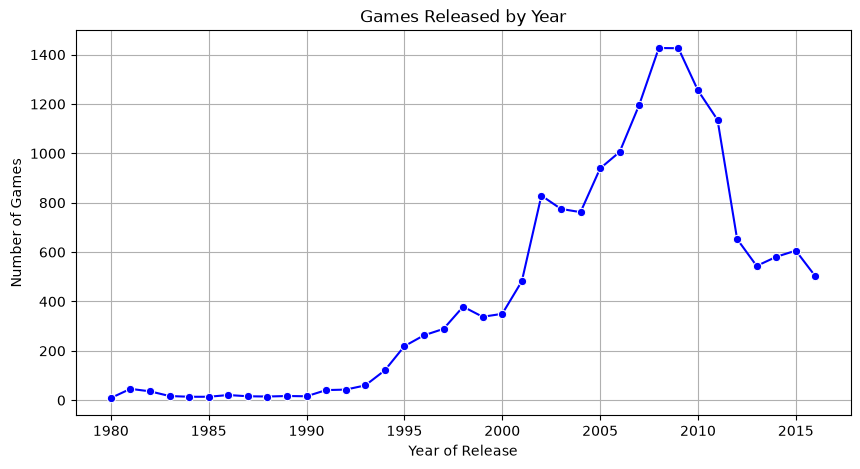

In [76]:
# Graph of releases by year

plt.figure(figsize=(10,5)) 
sns.lineplot(data=games_per_year, marker="o", color="blue")
plt.title('Games Released by Year')
plt.xlabel('Year of Release')
plt.ylabel('Number of Games')
plt.grid(True)
plt.show()

The chart suggests that release counts from before 2000 are less useful for this analysis: relatively few games were released, and the market was different.

The number of releases peaked **between 2006 and 2011**, then declined sharply. A shift toward mobile gaming may be one explanation, but this dataset alone cannot establish the cause. Release counts also do not tell us how well those games sold.

**3.2. Sales Trends and Platform Lifecycles**

In [77]:
# Top Platforms by Total Sales
top_platforms = game_data.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(6)
print(top_platforms)

platform
PS2     1062.33
X360     885.66
Wii      828.44
PS3      803.97
DS       746.86
PS       689.95
Name: total_sales, dtype: float64


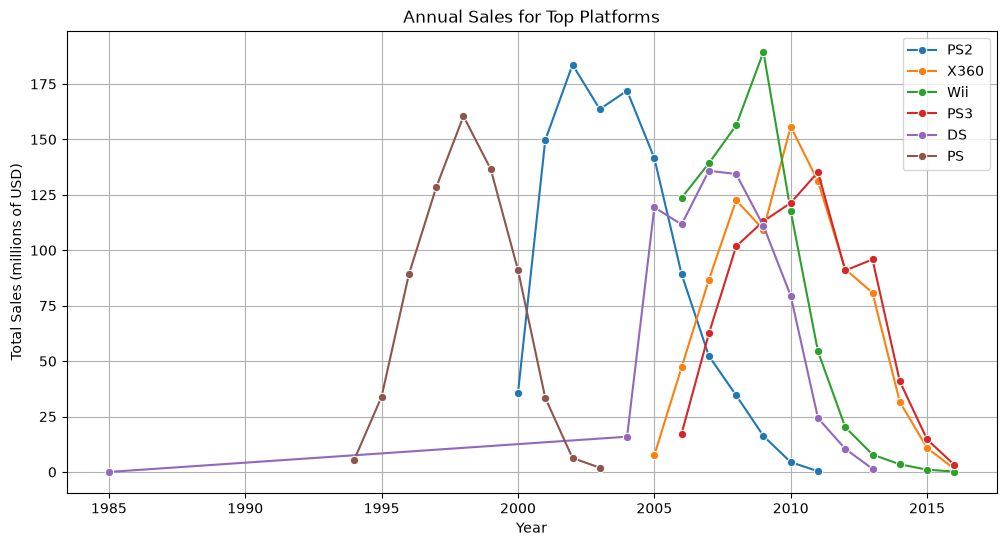

In [78]:
# Graph of annual sales for the top platforms
plt.figure(figsize=(12,6)) 

for platform in top_platforms.index:
    platform_data = game_data[game_data['platform'] == platform]
    
    annual_sales = (
        platform_data
        .groupby('year_of_release', as_index=False)['total_sales']
        .sum()
    )
    
    sns.lineplot(
        data=annual_sales, 
        x='year_of_release',
        y='total_sales',
        label=platform,
        marker="o"
    )

plt.title('Annual Sales for Top Platforms')
plt.xlabel('Year')
plt.ylabel('Total Sales (millions of USD)')
plt.grid(True)
plt.show()

- Platforms that were once popular but recorded no sales in the most recent year analyzed: PS2, DS, Wii, and Xbox 360.


- A successful platform appears to have a sales lifecycle of roughly 5 to 7 years. New console generations often emerge around the time the previous generation reaches its sales peak.

**3.3. Defining the Relevant Time Period**

In 2016, the PS4 and Xbox One were the leading consoles of the current generation. Therefore, I will focus on data from the years when these platforms were active.

In [79]:
relevant_data = game_data[game_data['year_of_release'] >= 2014].copy() 

**3.4. Market Trends**

In [80]:
platform_trends = relevant_data.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
).fillna(0)

print(platform_trends[['PS4','PS3', 'XOne', 'X360', 'PC', 'WiiU', '3DS']])

platform            PS4    PS3   XOne   X360     PC   WiiU    3DS
year_of_release                                                  
2014              84.22  40.88  49.26  31.61  12.38  20.35  41.75
2015             100.44  14.70  54.67  10.86   7.93  15.22  26.75
2016              59.01   3.23  23.91   1.40   4.89   4.25  14.50


Data from 2014 to 2016 show that the PS4 led sales by a wide margin, followed by the Xbox One and Nintendo 3DS. PC game sales remained relatively stable over this period.

**3.5. Boxplot Diagram**

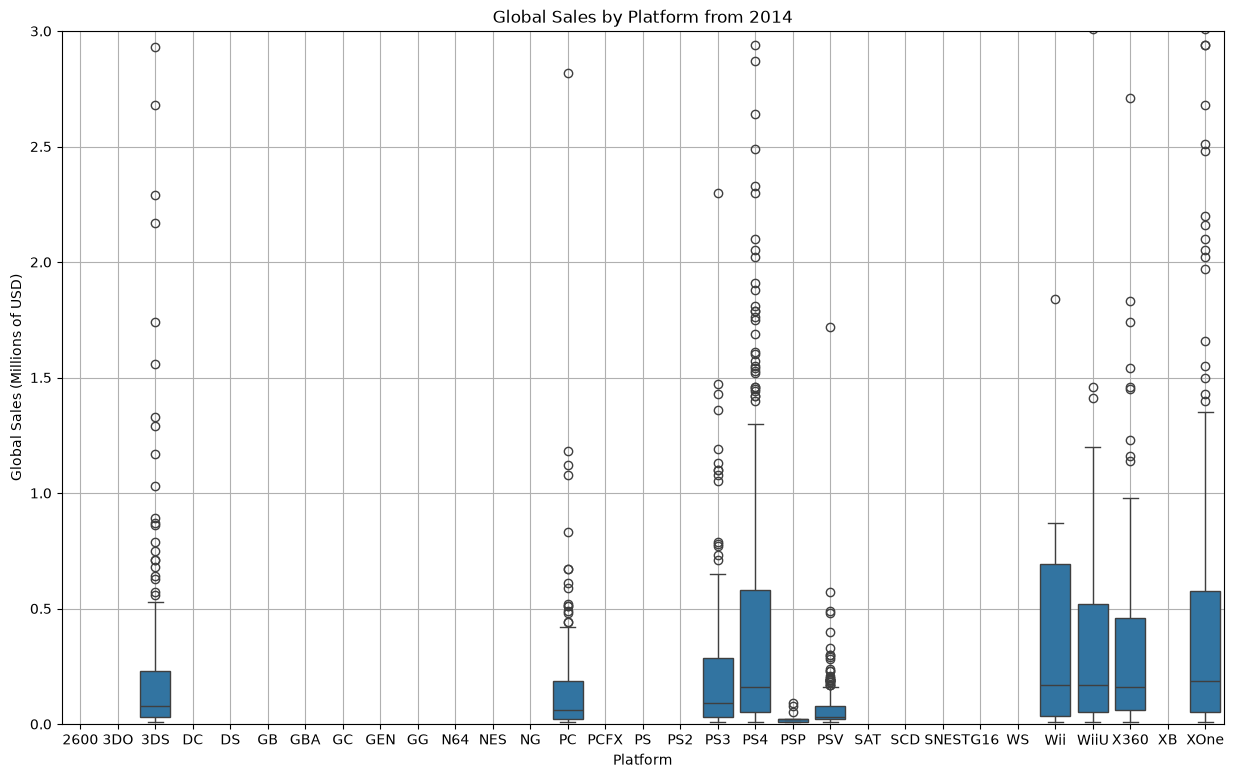

              mean  median       var       std
platform                                      
3DS       0.391509   0.080  1.260983  1.122935
PC        0.166887   0.060  0.092752  0.304553
PS3       0.268539   0.090  0.283978  0.532896
PS4       0.648059   0.160  1.846868  1.358995
PSP       0.027692   0.020  0.000769  0.027735
PSV       0.069797   0.030  0.015314  0.123748
Wii       0.424545   0.170  0.326727  0.571601
WiiU      0.545479   0.170  1.165503  1.079585
X360      0.395225   0.160  0.327116  0.571941
XOne      0.560702   0.185  0.906221  0.951956


In [81]:
plt.figure(figsize=(15,9))
sns.boxplot(
    data=relevant_data,
    x='platform',
    y='total_sales'
)

plt.title('Global Sales by Platform from 2014')
plt.xlabel('Platform')
plt.ylabel('Global Sales (Millions of USD)')

plt.ylim(0,3) # Limiting the y-axis to 3 million USD to better visualize the distribution of sales
plt.grid(True)
plt.show()

# Calculating mean, median, variance, and standard deviation of total sales for each platform

print(relevant_data.groupby('platform')['total_sales'].agg(['mean', 'median', 'var', 'std']))


The boxplot shows substantial differences in sales distributions across platforms. Major home consoles such as the PS4 and Xbox One have higher upper quartiles and whiskers than handheld platforms such as the PSP and 3DS.

The means are pulled upward by a small number of games with exceptionally high sales. In other words, blockbuster titles account for a disproportionate share of sales, particularly on the PS4 and Xbox One.

**3.6. The Relationship Between Review Scores and Sales** 

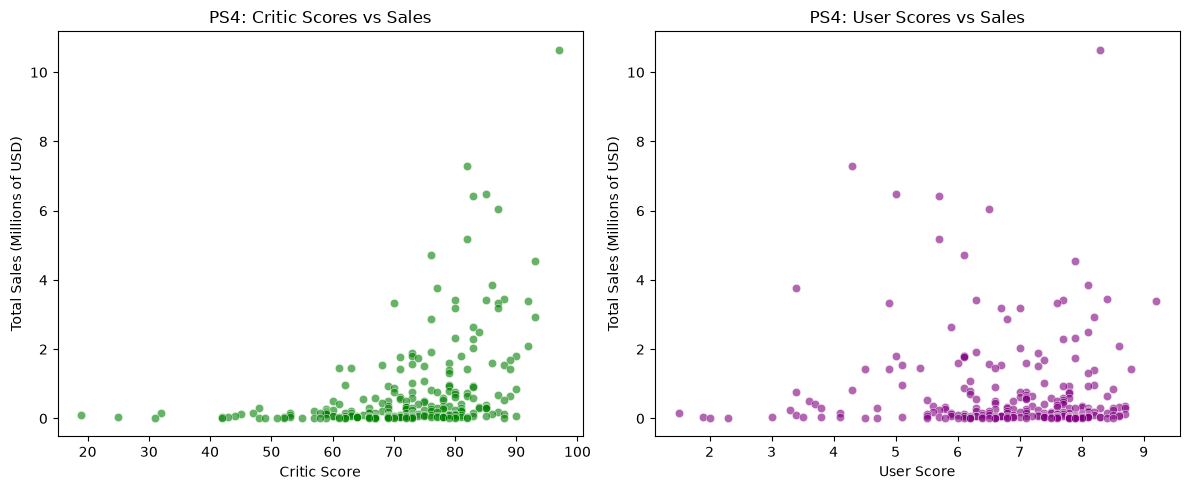

Games in critic analysis: 237
Correlation with critics: 0.402
Games in user analysis: 242
Correlation with users: -0.039


In [82]:
# Selecting only PS4 data for further analysis
ps4_data = relevant_data[relevant_data['platform'] == 'PS4']

# Cada análise usa apenas as colunas de que precisa
ps4_critic = ps4_data.dropna(subset=['critic_score', 'total_sales'])
ps4_user = ps4_data.dropna(subset=['user_score', 'total_sales'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=ps4_critic, x='critic_score', y='total_sales',
    alpha=0.6, color='green', ax=axes[0]
)
axes[0].set(
    title='PS4: Critic Scores vs Sales',
    xlabel='Critic Score',
    ylabel='Total Sales (Millions of USD)'
)

sns.scatterplot(
    data=ps4_user, x='user_score', y='total_sales',
    alpha=0.6, color='purple', ax=axes[1]
)
axes[1].set(
    title='PS4: User Scores vs Sales',
    xlabel='User Score',
    ylabel='Total Sales (Millions of USD)'
)

plt.tight_layout()
plt.show()

print(f"Games in critic analysis: {len(ps4_critic)}")
print(f"Correlation with critics: {ps4_critic['critic_score'].corr(ps4_critic['total_sales']):.3f}")

print(f"Games in user analysis: {len(ps4_user)}")
print(f"Correlation with users: {ps4_user['user_score'].corr(ps4_user['total_sales']):.3f}")

Critic scores show a moderate positive correlation with sales (around 0.40): games that receive higher scores from professional reviewers tend to sell more. User scores, by contrast, show little to no correlation with sales (around 0.00 to −0.05). This suggests that user scores are not a useful predictor of sales in this dataset; the correlations alone cannot establish whether either type of review affects sales.

**3.8. Comparing Multiplatform Games**

In [83]:
# finding games that were released on more than one platform in the relevant period
multiplatform_games = relevant_data.groupby('name').filter(lambda x: x['platform'].nunique() > 1)['name'].unique()

# Filtering the data for these specific games on the top-selling platforms
comp_data = relevant_data[relevant_data['name'].isin(multiplatform_games) & relevant_data['platform'].isin(['PS4', 'XOne', 'PC'])]

# Comparing the total sales by platform for the same games
pivot_comp = comp_data.pivot_table(index='name', columns='platform', values='total_sales')
print(pivot_comp.head(15)) # Displays a sample of the compared games

platform                                              PC   PS4  XOne
name                                                                
7 Days to Die                                        NaN  0.12  0.05
Adventure Time: Finn & Jake Investigations           NaN  0.08  0.05
Aegis of Earth: Protonovus Assault                   NaN  0.02   NaN
Agatha Christie's The ABC Murders                    NaN  0.02  0.01
Alien: Isolation                                    0.14  0.95  0.46
Arslan: The Warriors of Legend                       NaN  0.08  0.01
Assassin's Creed Chronicles                          NaN  0.07  0.01
Assassin's Creed Syndicate                          0.20  2.87  1.18
Assassin's Creed The Ezio Collection                 NaN  0.17  0.07
Assassin's Creed: Rogue                             0.07   NaN   NaN
Assassin's Creed: Unity                             0.51  3.34  3.17
Assetto Corsa                                        NaN  0.05  0.01
Atari Flashback Classics: Volume 1

The pattern in the relationship between review scores and sales appears across platforms. When comparing sales of the same multiplatform titles, the PS4 generally records higher sales than the Xbox One and PC. This is consistent with the PS4’s stronger sales performance during this console generation.

**3.9. Sales by Genre**

                 sum      mean  count
genre                                
Action        176.79  0.285606    619
Shooter       149.41  1.167266    128
Sports         95.12  0.590807    161
Role-Playing   92.80  0.419910    221
Misc           33.52  0.296637    113
Fighting       25.49  0.424833     60
Racing         24.63  0.356957     69
Platform       16.28  0.428421     38
Adventure      15.73  0.085027    185
Simulation     12.24  0.278182     44
Strategy        3.72  0.100541     37
Puzzle          2.10  0.150000     14


C:\Users\fredd\AppData\Local\Temp\ipykernel_27424\1176065593.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_analysis.index, y=genre_analysis['sum'], palette='magma')


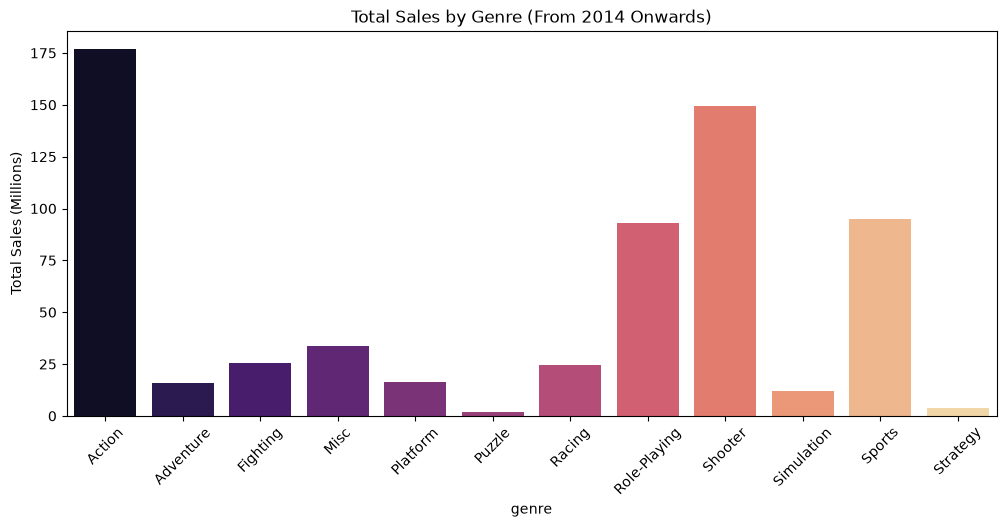

In [84]:
# Bar chart of total sales by genre for games released from 2014 onwards
genre_analysis = relevant_data.groupby('genre')['total_sales'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False)
print(genre_analysis)

plt.figure(figsize=(12, 5))
sns.barplot(x=genre_analysis.index, y=genre_analysis['sum'], palette='magma')
plt.title('Total Sales by Genre (From 2014 Onwards)')
plt.xticks(rotation=45)
plt.ylabel('Total Sales (Millions)')
plt.show()

- Genres with the highest sales: Action and Shooter lead in total sales, while Sports also performs strongly.

- Shooter, Action, and Sports have high total sales and relatively high average sales per game. Strategy, Puzzle, and Adventure show lower sales in this dataset. The number of titles released also varies by genre, so total sales and average sales per game should be considered separately.

## **4. Create a User Profile for Each Region**

In [85]:
regions = ['na_sales', 'eu_sales', 'jp_sales']
region_names = {'na_sales': 'North America', 'eu_sales': 'Europe', 'jp_sales': 'Japan'}

In [86]:
# 1. The top 5 platforms by region
print("TOP 5 PLATFORMS BY REGION")
for r in regions:
    top_plat = relevant_data.groupby('platform')[r].sum().sort_values(ascending=False).head(5)
    share = (top_plat / relevant_data[r].sum()) * 100
    print(f"\n{region_names[r]}:")
    for plat, val in top_plat.items():
        print(f"  {plat}: {val:.2f}M ({share[plat]:.1f}%)")



TOP 5 PLATFORMS BY REGION

North America:
  PS4: 98.61M (34.7%)
  XOne: 81.27M (28.6%)
  X360: 28.30M (10.0%)
  3DS: 22.64M (8.0%)
  PS3: 22.05M (7.8%)

Europe:
  PS4: 130.04M (48.0%)
  XOne: 46.25M (17.1%)
  PS3: 25.54M (9.4%)
  PC: 17.97M (6.6%)
  3DS: 16.12M (6.0%)

Japan:
  3DS: 44.24M (47.5%)
  PS4: 15.02M (16.1%)
  PSV: 14.54M (15.6%)
  PS3: 11.22M (12.1%)
  WiiU: 7.31M (7.9%)


In [87]:
# 2. The top 5 genres by region
print("TOP 5 GENRES BY REGION")
for r in regions:
    top_genre = relevant_data.groupby('genre')[r].sum().sort_values(ascending=False).head(5)
    print(f"\n{region_names[r]}:")
    for gen, val in top_genre.items():
        print(f"  {gen}: {val:.2f}M")


TOP 5 GENRES BY REGION

North America:
  Shooter: 79.02M
  Action: 72.53M
  Sports: 46.13M
  Role-Playing: 33.47M
  Misc: 15.05M

Europe:
  Action: 74.68M
  Shooter: 65.52M
  Sports: 45.73M
  Role-Playing: 28.17M
  Racing: 14.13M

Japan:
  Role-Playing: 31.16M
  Action: 29.58M
  Fighting: 6.37M
  Misc: 5.61M
  Shooter: 4.87M


In [88]:
# 3. Impact of ESRB ratings on sales
print("SALES BY ESRB RATING")
for r in regions:
    # Preenchendo nulos temporariamente para não ignorar jogos sem classificação na contagem visual
    esrb_sales = relevant_data.groupby('rating')[r].sum().sort_values(ascending=False)
    print(f"\n{region_names[r]}:")
    for rat, val in esrb_sales.items():
        if val > 0:
            print(f"  {rat}: {val:.2f}M")


SALES BY ESRB RATING

North America:
  M: 96.42M
  E: 50.74M
  T: 38.95M
  E10+: 33.23M

Europe:
  M: 93.44M
  E: 58.06M
  T: 34.07M
  E10+: 26.16M

Japan:
  T: 14.78M
  E: 8.94M
  M: 8.01M
  E10+: 4.46M


**1. Top five platforms and market shares**

- **North America**: The PS4 leads, with the Xbox One holding a much larger share than it does in the other regions. The 3DS, Xbox 360, and PS3 complete the top five with smaller shares.

- **Europe**: The PS4 dominates sales, while the Xbox One is a distant second. PC sales are also more prominent here than in the other regions.

**Japan**: The 3DS leads, followed by the PS4 and PS Vita. Xbox One sales are minimal.

Regional comparison: Home consoles lead in North America and Europe, while handheld platforms have a much stronger presence in Japan. The sales data show this difference but do not establish what causes it.

**2. Top five genres and regional differences**

- **North America** and **Europe**: Shooter and Action are among the leading genres, with Sports and Role-Playing also performing strongly.

- **Japan**: Role-Playing leads, followed by Action. Shooter has a much smaller share than it does in North America and Europe.

These patterns suggest that a campaign tailored to each region could emphasize different genres. The dataset does not, however, tell us why consumers prefer them.

**3. ESRB ratings and regional sales**

- **North America** and **Europe**: Games rated M (Mature) and E (Everyone) account for a large share of recorded sales. This describes sales by rating; it does not show that the rating itself caused higher sales.

- **Japan**: Too many ESRB ratings are missing to draw a reliable conclusion about sales by rating in this region.

## **5. Hypothesis Tests**

In [89]:
# Select valid user scores for each platform
xbox_scores = relevant_data[
    (relevant_data['platform'] == 'XOne') &
    (relevant_data['user_score'].notna())
]['user_score']

pc_scores = relevant_data[
    (relevant_data['platform'] == 'PC') &
    (relevant_data['user_score'].notna())
]['user_score']

alpha = 0.05

# Welch's t-test: does not assume equal variances
t_stat1, p_value1 = stats.ttest_ind(
    xbox_scores,
    pc_scores,
    equal_var=False
)

print("Test 1: User Scores (Xbox One vs PC)")
print(f"Xbox One mean: {xbox_scores.mean():.2f} | PC mean: {pc_scores.mean():.2f}")
print(f"p-value: {p_value1:.4f}")

if p_value1 < alpha:
    print("Result: Reject the null hypothesis. There is evidence that the mean user scores differ.")
else:
    print("Result: Fail to reject the null hypothesis. There is insufficient evidence that the mean user scores differ.")

Test 1: User Scores (Xbox One vs PC)
Xbox One mean: 6.59 | PC mean: 6.30
p-value: 0.1160
Result: Fail to reject the null hypothesis. There is insufficient evidence that the mean user scores differ.


In [90]:
action_scores = relevant_data[
    (relevant_data['genre'] == 'Action') &
    (relevant_data['user_score'].notna())
]['user_score']

sports_scores = relevant_data[
    (relevant_data['genre'] == 'Sports') &
    (relevant_data['user_score'].notna())
]['user_score']

alpha = 0.05

# Perform a two-sided Welch's t-test
t_stat2, p_value2 = stats.ttest_ind(
    action_scores,
    sports_scores,
    equal_var=False
)

print("\n--- Test 2: User Scores (Action vs Sports) ---")
print(f"Action mean: {action_scores.mean():.2f} | Sports mean: {sports_scores.mean():.2f}")
print(f"p-value: {p_value2:.4f}")

if p_value2 < alpha:
    print("Result: Reject the null hypothesis. There is evidence that the mean user scores differ.")
else:
    print("Result: Fail to reject the null hypothesis. There is insufficient evidence that the mean user scores differ.")


--- Test 2: User Scores (Action vs Sports) ---
Action mean: 6.76 | Sports mean: 5.23
p-value: 0.0000
Result: Reject the null hypothesis. There is evidence that the mean user scores differ.


## **6. Findings**

Based on the exploratory and statistical analysis of video game sales and review data, this study focuses on **2014–2016** to inform planning for 2017.

# 1. Platform Lifecycles and Market Dynamics

- **Platform lifecycles:** The platforms analyzed show periods of growth, peak sales, and decline. Among the successful platforms observed, the period of strongest sales appears to last approximately **5 to 7 years**. This is a pattern in the dataset, not a fixed rule for every platform.
- **Game releases over time:** The number of games recorded in the dataset peaked between 2006 and 2011, then declined. The data show this change but do not establish its cause.
- **Time period for 2017 planning:** The analysis uses **2014–2016** to examine platforms most relevant to 2017. Earlier years help illustrate platform lifecycles but are excluded from comparisons of the recent market. Data for 2016 may be incomplete.

# 2. Platform Strategy and Sales

- **PS4 stands out:** The **PS4** recorded the highest sales among the leading platforms during the selected period, making it an important platform to consider for the 2017 campaign.
- **Other relevant platforms:** The **Xbox One (XOne)** had a substantial presence, particularly in North America. The **PC** also remained active throughout the period. Platform priorities should account for regional differences.
- **Sales concentration:** The boxplots show that a small number of games sold far more than most others. These high-selling titles can pull average sales upward, so the **median and the distribution of sales per game** should also inform platform comparisons.

# 3. Regional Consumer Profiles

Sales patterns differ across regions, suggesting that the campaign should be adapted to each market:

- **North America (NA):** Both the PS4 and Xbox One have substantial market shares. **Shooter** and **Action** are among the leading genres. Games rated **M** (*Mature*) and **E** (*Everyone*) account for significant shares of recorded sales.
- **Europe (EU):** The **PS4** leads by a wider margin over the Xbox One. **Shooter** and **Action** also perform strongly.
- **Japan (JP):** The **Nintendo 3DS** and other handheld platforms have a stronger presence than they do in Western markets. **Role-Playing** stands out among genres. Because many ESRB ratings are missing, the data do not support a reliable conclusion about the relationship between ESRB ratings and sales in Japan.

# 4. The Relationship Between Review Scores and Sales

- **Critic scores:** On the platform analyzed, professional critic scores showed a **moderate positive correlation** with sales, around **0.40**. Games with higher critic scores tended to have higher sales.
- **User scores:** The correlation between user scores and sales was **close to zero** in the same analysis. User scores therefore showed no clear linear relationship with recorded sales.

These correlations describe associations in the data. They do not establish that reviews caused sales to rise or fall.

# 5. Statistical Hypothesis Tests

The statements below depend on the *p-values* obtained after running the tests with **α = 0.05**. Because the code uses `equal_var=False`, the method is **Welch’s t-test**.

- **Xbox One vs. PC:** If the *p-value* is **greater than or equal to 0.05**, we fail to reject the null hypothesis. The data then provide insufficient evidence that the mean user scores differ. This does **not** prove that the means are equal.
- **Action vs. Sports:** If the *p-value* is **below 0.05**, we reject the null hypothesis. This provides statistical evidence that the mean user scores differ. To state **which genre has the lower mean score**, the calculated means must also be compared.

Overall, the findings support planning the 2017 campaign by **platform, genre, and region**, while accounting for sales concentrated in a small number of titles and the possibility that the 2016 data are incomplete.